# 03 · Apollo 4 Reentry: Validation Against NASA Flight Data

This notebook validates the `reentrykit` trajectory simulator against the Apollo 4 (AS-501) flight reconstruction published in **NASA TN D-5399** (Hilje 1969). Apollo 4 was the first Saturn V test flight and the first Earth reentry at lunar-return velocity — its extensive instrumentation and the subsequent detailed flight reconstruction make it the definitive validation target for reentry trajectory codes.

## Scope

This notebook focuses on Apollo 4 because:

1. **Primary-source flight data is available** — NASA TN D-5399 contains complete time histories of altitude, velocity, and deceleration, plus the commanded L/D history used by the guidance system
2. **An independent published simulation exists** — Tetzman (2010, M.S. Thesis, University of Minnesota) reproduces this reentry with comparable methodology, giving us two validation targets
3. **The mission covered a wide range of reentry physics** — skip-glide trajectory with active lift modulation, peak deceleration at lunar-return velocity, substantial altitude variation

## What our simulator does

- **3-DOF equations of motion** for a point-mass vehicle over a non-rotating spherical Earth (Vinh-Busemann-Culp formulation)
- **Physical aero parameters**: mass, reference area, drag coefficient (constant or Mach-dependent), lift-to-drag ratio (constant or time-varying callable)
- **US1976 atmosphere** from 0–86 km, with exponential extension to 200 km
- **Skip-out event handling** for trajectories that depart the atmosphere permanently

## Four configurations

To illustrate how lift modulation dominates Apollo-class physics, we run four variants at Apollo's actual entry conditions:

1. **Pure ballistic** (L/D = 0): bounds the problem from above
2. **Constant L/D = 0.52**: crude constant-lift approximation
3. **Tetzman's 19-interval schedule**: our prior validation target (piecewise-constant L/D)
4. **High-resolution Hilje schedule**: continuously-digitized L/D history from NASA TN D-5399 (200+ points)

## References

- Hilje, E.R. (1969). *Entry Aerodynamics at Lunar Return Conditions Obtained from the Flight of Apollo 4 (AS-501)*. NASA TN D-5399.
- Tetzman, D.G. (2010). *Simulation and Optimization of Spacecraft Re-entry Trajectories*. M.S. Thesis, University of Minnesota.
- Allen, H.J. and Eggers, A.J. (1958). *A Study of the Motion and Aerodynamic Heating of Ballistic Missiles Entering the Earth's Atmosphere at High Supersonic Speeds*. NACA Report 1381.

In [1]:
"""Imports, constants, and shared helper functions."""

import numpy as np
import matplotlib.pyplot as plt

from reentrykit.trajectory import Vehicle, InitialState, simulate
from reentrykit.atmosphere import MAX_ALTITUDE, MAX_EXTENDED_ALTITUDE, us1976


def peak_deceleration(result):
    """Return (peak g, peak altitude [km], time of peak [s]) from a trajectory."""
    dV_dt = np.gradient(result.velocity, result.time)
    i_peak = dV_dt.argmin()
    peak_g = -dV_dt[i_peak] / 9.80665
    peak_alt_km = result.altitude[i_peak] / 1000.0
    peak_time = result.time[i_peak]
    return peak_g, peak_alt_km, peak_time


def allen_eggers_prediction(
    entry_velocity: float,
    entry_flight_path_angle: float,
    scale_height: float = 6930.0,
) -> float:
    """Peak deceleration [g] from Allen-Eggers (1958) closed-form analytical solution.

    Uses scale height H = 6.93 km matching Tetzman (2010) for Earth's atmosphere
    in the range where peak deceleration typically occurs (30-60 km).
    """
    peak_accel = (
        entry_velocity**2 * abs(np.sin(entry_flight_path_angle)) / (2 * np.e * scale_height)
    )
    return peak_accel / 9.80665


print(f"Atmosphere: US1976 validated to {MAX_ALTITUDE/1000:.0f} km, extended to {MAX_EXTENDED_ALTITUDE/1000:.0f} km")
print("Helpers ready: peak_deceleration(), allen_eggers_prediction()")

Atmosphere: US1976 validated to 86 km, extended to 200 km
Helpers ready: peak_deceleration(), allen_eggers_prediction()


## Apollo 4 (AS-501, November 1967)

Apollo 4 flew a guided skip-glide trajectory using offset center-of-gravity lift, modulating bank angle continuously to manage peak deceleration and target the splashdown site.

### Published reference values (Hilje 1969)

- Entry interface: **121.92 km** (400,000 ft)
- Entry velocity: **11,137 m/s**
- Entry flight-path angle: **−6.93°**
- Peak deceleration (first peak): **7.3 g** at t ≈ 74 s post-entry
- Second peak: **4.25 g** at t ≈ 464 s post-entry
- Command module mass: 5,357 kg
- Heat shield diameter: 3.9 m → reference area = 12.0 m²
- Hypersonic Cd: ~1.2
- L/D magnitude: 0.368 from offset CG; "vertical L/D" varies from −0.5 to +0.5 via bank-angle modulation

In [2]:
"""Run four configurations of Apollo 4 at the real 121.92 km entry interface."""

# Apollo 4 vehicle parameters (Hilje 1969)
APOLLO_MASS = 5357.0              # [kg]
APOLLO_AREA = 12.0                # [m^2]
APOLLO_CD = 1.2                   # [-] constant hypersonic Cd
APOLLO_NOSE_RADIUS = 4.661        # [m]

# Entry conditions at Apollo's actual entry interface
apollo_state = InitialState(
    altitude=121_920.0,                          # 400,000 ft
    velocity=11_137.0,                           # lunar-return velocity
    flight_path_angle=np.deg2rad(-6.93),         # Hilje 1969
)


# --- Configuration 1: Pure ballistic (L/D = 0) ---
apollo_ballistic = Vehicle.from_mass_area_cd(
    mass=APOLLO_MASS,
    reference_area=APOLLO_AREA,
    drag_coefficient=APOLLO_CD,
    lift_to_drag_ratio=0.0,
    nose_radius=APOLLO_NOSE_RADIUS,
)
result_ballistic = simulate(apollo_ballistic, apollo_state, max_time=3000.0)
peak_bg, peak_balt, _ = peak_deceleration(result_ballistic)


# --- Configuration 2: Constant L/D = 0.52 ---
apollo_constant = Vehicle.from_mass_area_cd(
    mass=APOLLO_MASS,
    reference_area=APOLLO_AREA,
    drag_coefficient=APOLLO_CD,
    lift_to_drag_ratio=0.52,
    nose_radius=APOLLO_NOSE_RADIUS,
)
result_constant = simulate(apollo_constant, apollo_state, max_time=3000.0)
peak_cg, peak_calt, _ = peak_deceleration(result_constant)


# --- Configuration 3: Tetzman's 19-interval piecewise-constant L/D ---
TETZMAN_LD_SCHEDULE = [
    -0.07,  0.35,  0.37, -0.35,  0.26,  0.00, -0.01,
     0.19,  0.28,  0.33,  0.28,  0.12,  0.08,  0.16,
     0.18,  0.23,  0.29,  0.24,  0.15,
]
TETZMAN_INTERVAL_DURATION = 30.0  # [s]


def tetzman_schedule(t: float) -> float:
    """Apollo 4 L/D from Tetzman (2010) Figure 3.4, piecewise-constant 30s intervals."""
    index = int(t // TETZMAN_INTERVAL_DURATION)
    if index >= len(TETZMAN_LD_SCHEDULE):
        index = len(TETZMAN_LD_SCHEDULE) - 1
    return TETZMAN_LD_SCHEDULE[index]


apollo_tetzman = Vehicle.from_mass_area_cd(
    mass=APOLLO_MASS,
    reference_area=APOLLO_AREA,
    drag_coefficient=APOLLO_CD,
    lift_to_drag_ratio=tetzman_schedule,
    nose_radius=APOLLO_NOSE_RADIUS,
)
result_tetzman = simulate(apollo_tetzman, apollo_state, max_time=3000.0)
peak_tg, peak_talt, _ = peak_deceleration(result_tetzman)


# --- Configuration 4: High-resolution Hilje L/D schedule ---
# Digitized from NASA TN D-5399 Figure 3 (Apollo 4 commanded vertical L/D trace).
APOLLO_ENTRY_INTERFACE_GET = 29968.54  # [s] ground elapsed time per Hilje p.6

APOLLO_HIRES_GET = np.array([
    29968.5, 29970.7, 29972.5, 29974.9, 29979.2, 29982.1, 29983.8, 29985.3, 29987.4,
    29989.5, 29991.7, 29993.8, 29996.3, 29999.1, 30001.3, 30004.1, 30005.2, 30007.3,
    30008.4, 30012.7, 30015.5, 30016.9, 30019.1, 30021.2, 30026.2, 30027.6, 30033.3,
    30036.9, 30041.1, 30045.8, 30051.1, 30054.0, 30055.7, 30057.9, 30059.3, 30061.8,
    30064.6, 30066.4, 30068.9, 30071.0, 30073.5, 30076.0, 30078.2, 30081.0, 30083.1,
    30085.6, 30088.8, 30089.6, 30091.7, 30092.8, 30095.2, 30096.7, 30097.7, 30099.5,
    30100.6, 30103.1, 30105.6, 30107.3, 30108.4, 30109.8, 30111.3, 30113.8, 30115.9,
    30117.7, 30119.8, 30121.6, 30123.7, 30125.1, 30127.6, 30129.4, 30132.6, 30134.8,
    30137.2, 30140.1, 30142.9, 30145.1, 30149.0, 30150.1, 30155.7, 30158.2, 30161.8,
    30164.6, 30165.0, 30169.3, 30172.5, 30175.3, 30177.8, 30180.0, 30182.1, 30183.2,
    30186.7, 30187.8, 30189.9, 30192.4, 30193.8, 30194.9, 30197.7, 30200.2, 30202.7,
    30203.8, 30205.9, 30209.1, 30209.8, 30212.0, 30213.4, 30215.9, 30218.0, 30220.2,
    30221.6, 30224.4, 30225.5, 30228.0, 30230.1, 30235.8, 30238.7, 30242.2, 30245.4,
    30247.2, 30250.1, 30251.5, 30252.9, 30257.5, 30259.3, 30261.8, 30263.6, 30265.7,
    30267.5, 30270.7, 30271.4, 30274.6, 30276.0, 30278.2, 30279.6, 30282.1, 30283.2,
    30286.4, 30287.8, 30290.6, 30292.4, 30294.9, 30295.6, 30298.1, 30301.0, 30303.8,
    30305.6, 30307.0, 30309.5, 30312.3, 30314.1, 30316.3, 30318.4, 30320.5, 30322.3,
    30324.8, 30326.9, 30327.7, 30329.4, 30332.3, 30334.8, 30336.2, 30338.0, 30339.4,
    30341.5, 30343.0, 30345.8, 30350.4, 30351.9, 30354.0, 30356.8, 30357.5, 30360.4,
    30362.2, 30364.0, 30366.1, 30367.9, 30370.4, 30371.1, 30375.0, 30380.3, 30389.2,
    30396.7, 30401.3, 30403.8, 30409.9, 30418.4, 30423.0, 30424.5, 30426.2, 30428.4,
    30430.2, 30432.3, 30434.4, 30436.2, 30437.6, 30440.1, 30442.6, 30445.1, 30446.5,
    30448.7, 30449.7, 30452.2, 30454.4, 30455.4, 30457.9, 30460.8, 30462.2, 30464.3,
    30465.7, 30468.6, 30470.7, 30474.6, 30476.8, 30478.2, 30482.5, 30486.4, 30489.9,
    30492.1, 30494.6, 30496.4, 30497.8, 30499.2, 30502.8, 30504.9, 30505.6, 30508.1,
    30509.5, 30511.3, 30514.1, 30516.3, 30518.8, 30521.3, 30526.2, 30531.9, 30533.0,
    30534.1, 30535.5, 30537.3, 30540.5, 30542.3, 30544.0, 30545.8, 30548.3, 30550.4,
    30555.4, 30556.1, 30558.3, 30561.8, 30564.0, 30566.1, 30567.9, 30570.0, 30573.6,
    30576.1, 30578.6, 30581.1, 30582.8, 30584.6, 30586.8, 30588.9, 30592.1, 30592.1,
    30594.6, 30596.4, 30598.1, 30600.3, 30602.4, 30604.2, 30606.7, 30608.1, 30610.2,
    30613.1, 30613.8, 30616.6, 30618.8, 30621.3, 30624.1, 30627.3, 30629.8, 30630.2,
    30632.0, 30635.2, 30636.6, 30639.4, 30639.4, 30643.0, 30644.8, 30648.0, 30651.5,
    30654.7, 30657.6, 30658.6, 30660.1, 30663.3, 30665.4, 30665.8, 30668.3, 30670.0,
    30673.2, 30674.3, 30677.9,
])

APOLLO_HIRES_LD = np.array([
    -0.490606, -0.491460, -0.493168, -0.496584,  0.254910,  0.166097,  0.359095,
     0.310418,  0.255764,  0.297609,  0.345431,  0.330914,  0.344577,  0.346285,
     0.346285,  0.347139,  0.339453,  0.345431,  0.361657,  0.359949,  0.360803,
     0.357387,  0.355679,  0.353971,  0.353971,  0.357387,  0.359095,  0.366781,
     0.370196,  0.371904,  0.369342,  0.362511,  0.302733,  0.145602, -0.018360,
    -0.082408, -0.164389, -0.297609, -0.358241, -0.355679, -0.353971, -0.353971,
    -0.355679, -0.358241, -0.357387, -0.295901, -0.132792,  0.090948,  0.272844,
     0.344577,  0.341161,  0.336038,  0.328352,  0.319812,  0.313834,  0.307857,
     0.303587,  0.295047,  0.287361,  0.280529,  0.271990,  0.252348,  0.224167,
     0.184031,  0.146456,  0.111443,  0.089240,  0.063621,  0.038002,  0.014945,
    -0.006405, -0.006405, -0.001281, -0.000427, -0.002989, -0.006405, -0.012383,
    -0.015799, -0.010675, -0.009821, -0.014945, -0.016652,  0.000427,  0.002989,
     0.025192,  0.042272,  0.061913,  0.063621,  0.083262,  0.092656,  0.102904,
     0.131939,  0.140478,  0.144748,  0.162681,  0.172929,  0.179761,  0.200256,
     0.207942,  0.216482,  0.244663,  0.260888,  0.269428,  0.277114,  0.284799,
     0.274552,  0.267720,  0.263450,  0.251494,  0.257472,  0.272844,  0.269428,
     0.278822,  0.285653,  0.289069,  0.290777,  0.290777,  0.283945,  0.287361,
     0.296755,  0.307857,  0.325790,  0.335184,  0.368488,  0.361657,  0.353971,
     0.360803,  0.358241,  0.353971,  0.357387,  0.362511,  0.350555,  0.338599,
     0.326644,  0.311272,  0.301025,  0.280529,  0.260888,  0.253202,  0.226729,
     0.210504,  0.198548,  0.172929,  0.180615,  0.160120,  0.164389,  0.169513,
     0.162681,  0.154142,  0.126815,  0.097780,  0.081554,  0.070453,  0.080700,
     0.084970,  0.094364,  0.101196,  0.106319,  0.102904,  0.085824,  0.078992,
     0.072161,  0.065329,  0.058497,  0.054227,  0.061913,  0.076430,  0.090948,
     0.089240,  0.104611,  0.129377,  0.147310,  0.166097,  0.176345,  0.171221,
     0.161827,  0.158412,  0.149872,  0.147310,  0.148164,  0.149872,  0.166951,
     0.184031,  0.189155,  0.190863,  0.197694,  0.203672,  0.238685,  0.324936,
     0.336038,  0.224167,  0.137916,  0.143894,  0.165243,  0.179761,  0.187447,
     0.190009,  0.181469,  0.174637,  0.162681,  0.206234,  0.312980,  0.368488,
     0.359949,  0.344577,  0.331768,  0.316396,  0.301025,  0.283945,  0.261742,
     0.219044,  0.204526,  0.193424,  0.196840,  0.201964,  0.203672,  0.195132,
     0.180615,  0.168659,  0.154142,  0.146456,  0.142186,  0.201964,  0.318958,
     0.359095,  0.236123,  0.080700,  0.047395,  0.080700,  0.108027,  0.130231,
     0.132792,  0.124253,  0.139624,  0.167805,  0.201964,  0.263450,  0.357387,
     0.368488,  0.311272,  0.277114,  0.266866,  0.256618,  0.256618,  0.243809,
     0.220751,  0.212212,  0.237831,  0.283945,  0.318104,  0.344577,  0.358241,
     0.343723,  0.364219,  0.401793,  0.343723,  0.176345,  0.083262,  0.084116,
     0.086678,  0.125107,  0.226729,  0.237831,  0.090948,  0.058497,  0.241247,
     0.391546,  0.340307,  0.181469,  0.099488,  0.135354,  0.178907,  0.201964,
     0.210504,  0.215628,  0.215628,  0.213066,  0.218190,  0.237831,  0.280529,
     0.305295,  0.324082,  0.352263,  0.365073,  0.378736,  0.369342,  0.362511,
     0.357387,  0.358241,  0.356533,  0.342015,  0.324936,  0.324936,  0.340307,
     0.353117,  0.361657,  0.337746,  0.313834,  0.324082,  0.313834,
])

# Convert ground elapsed time to "time since entry interface"
APOLLO_HIRES_TIME = APOLLO_HIRES_GET - APOLLO_ENTRY_INTERFACE_GET


def apollo_highres_schedule(t: float) -> float:
    """Apollo 4 L/D from a high-resolution digitization of NASA TN D-5399 Figure 3.

    Uses linear interpolation between digitized (time, L/D) pairs. Clamps to
    nearest value before the first point or after the last.
    """
    if t <= APOLLO_HIRES_TIME[0]:
        return APOLLO_HIRES_LD[0]
    if t >= APOLLO_HIRES_TIME[-1]:
        return APOLLO_HIRES_LD[-1]
    return float(np.interp(t, APOLLO_HIRES_TIME, APOLLO_HIRES_LD))


apollo_highres = Vehicle.from_mass_area_cd(
    mass=APOLLO_MASS,
    reference_area=APOLLO_AREA,
    drag_coefficient=APOLLO_CD,
    lift_to_drag_ratio=apollo_highres_schedule,
    nose_radius=APOLLO_NOSE_RADIUS,
)
result_highres = simulate(apollo_highres, apollo_state, max_time=3000.0)
peak_hg, peak_halt, peak_htime = peak_deceleration(result_highres)


# --- Allen-Eggers analytical reference ---
ae_apollo = allen_eggers_prediction(
    apollo_state.velocity,
    apollo_state.flight_path_angle,
)


# --- Summary ---
print("=" * 84)
print(f"{'Apollo 4 Reentry — Four Configurations':^84}")
print("=" * 84)
print(f"\n{'Configuration':<44} {'Peak g':>10} {'Peak alt':>14} {'Termination':>14}")
print("-" * 84)
print(f"{'Allen-Eggers analytical (ballistic)':<44} {ae_apollo:>10.2f} {'—':>14} {'—':>14}")
print(f"{'Our simulator, ballistic (L/D=0)':<44} {peak_bg:>10.2f} {peak_balt:>11.1f} km   {result_ballistic.termination_reason[:14]:>14}")
print(f"{'Our simulator, constant L/D=0.52':<44} {peak_cg:>10.2f} {peak_calt:>11.1f} km   {result_constant.termination_reason[:14]:>14}")
print(f"{'Our simulator, Tetzman 19-interval schedule':<44} {peak_tg:>10.2f} {peak_talt:>11.1f} km   {result_tetzman.termination_reason[:14]:>14}")
print(f"{'Our simulator, high-res Hilje schedule':<44} {peak_hg:>10.2f} {peak_halt:>11.1f} km   {result_highres.termination_reason[:14]:>14}")
print(f"{'Tetzman 2010 published (19-interval)':<44} {7.91:>10.2f} {'—':>14} {'—':>14}")
print(f"{'Apollo 4 flight (Hilje 1969)':<44} {7.30:>10.2f} {'—':>14} {'—':>14}")

                       Apollo 4 Reentry — Four Configurations                       

Configuration                                    Peak g       Peak alt    Termination
------------------------------------------------------------------------------------
Allen-Eggers analytical (ballistic)               40.51              —              —
Our simulator, ballistic (L/D=0)                  20.21        40.9 km    Ground impact
Our simulator, constant L/D=0.52                   6.33        56.4 km   Skip-out above
Our simulator, Tetzman 19-interval schedule        7.82        54.1 km    Ground impact
Our simulator, high-res Hilje schedule             7.78        54.1 km    Ground impact
Tetzman 2010 published (19-interval)               7.91              —              —
Apollo 4 flight (Hilje 1969)                       7.30              —              —


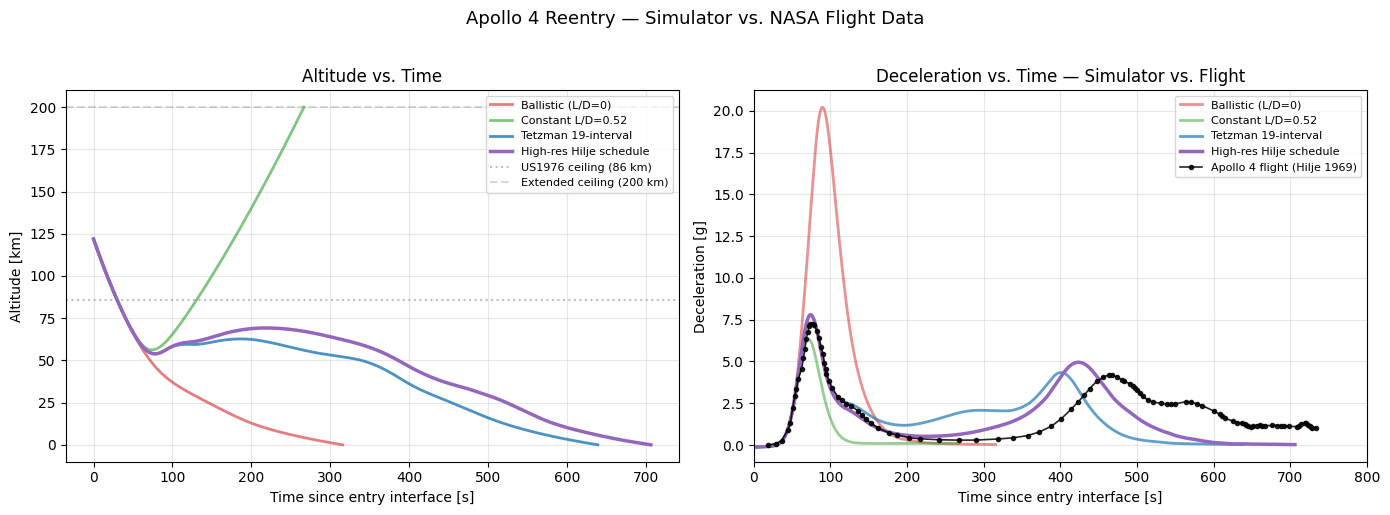


                 High-res Hilje Schedule vs. Apollo 4 Flight                  
Metric                                        Simulator         Flight      Error
------------------------------------------------------------------------------
First peak magnitude [g]                           7.78           7.26      +7.1%
First peak time [s post-entry]                       74             74      +0.6%
Second peak magnitude [g]                          4.95           4.21     +17.7%
Second peak time [s post-entry]                     424            463      -8.6%


In [3]:
"""Overlay simulated trajectories against digitized Apollo 4 flight deceleration data."""

# Apollo 4 measured deceleration from NASA TN D-5399 Figure 21
apollo_flight_get = np.array([
    29987.7, 29997.4, 30005.1, 30013.2, 30016.3, 30019.4, 30022.2, 30024.1, 30026.4,
    30031.1, 30033.4, 30035.4, 30036.6, 30039.3, 30040.5, 30042.4, 30045.5, 30047.4,
    30050.8, 30053.5, 30056.2, 30058.9, 30060.8, 30062.3, 30063.4, 30066.9, 30071.1,
    30078.4, 30083.4, 30089.5, 30095.7, 30104.2, 30109.5, 30114.5, 30121.1, 30131.1,
    30144.9, 30155.3, 30171.5, 30185.0, 30210.8, 30236.6, 30258.5, 30287.0, 30307.1,
    30325.9, 30341.0, 30356.4, 30369.1, 30382.6, 30392.3, 30400.0, 30407.0, 30416.2,
    30424.3, 30432.0, 30436.3, 30443.2, 30448.6, 30452.0, 30459.7, 30463.6, 30465.5,
    30468.6, 30472.4, 30476.3, 30482.4, 30489.0, 30499.4, 30508.2, 30512.5, 30517.8,
    30532.9, 30538.7, 30546.3, 30554.0, 30569.1, 30576.7, 30579.4, 30583.3, 30593.3,
    30599.4, 30605.6, 30609.5, 30611.4, 30613.7, 30616.8, 30620.2, 30624.9, 30628.7,
    30632.2, 30636.0, 30644.5, 30651.4, 30656.8, 30660.7, 30666.5, 30676.9, 30679.9,
    30682.6, 30687.3, 30688.8, 30692.3, 30693.8, 30695.3, 30696.9, 30702.3,
])
apollo_flight_g = np.array([
    0.00462, 0.08786, 0.26821, 0.92023, 1.30405, 2.20578, 2.95954, 3.37110, 3.94913,
    4.54566, 5.21618, 5.75723, 6.33988, 6.75607, 7.13064, 7.26474, 7.26012, 7.16763,
    6.84855, 6.41387, 5.87283, 5.44740, 4.88324, 4.56879, 4.25896, 3.85202, 3.39422,
    2.88092, 2.66821, 2.47399, 2.33526, 2.05780, 1.80347, 1.58613, 1.32717, 1.00809,
    0.73064, 0.60116, 0.43006, 0.37457, 0.31445, 0.29133, 0.29595, 0.36069, 0.43006,
    0.56416, 0.77688, 1.10983, 1.53988, 2.13642, 2.59884, 2.99653, 3.38035, 3.81503,
    4.05087, 4.20809, 4.20809, 4.04624, 3.90751, 3.80116, 3.66705, 3.56069, 3.44046,
    3.29249, 3.08902, 2.90405, 2.70520, 2.58035, 2.50173, 2.42775, 2.46474, 2.45549,
    2.59884, 2.56647, 2.47399, 2.35376, 2.03006, 1.83584, 1.71098, 1.59538, 1.44740,
    1.34104, 1.30405, 1.26243, 1.19306, 1.14220, 1.10520, 1.13295, 1.16532, 1.18844,
    1.16069, 1.16069, 1.16994, 1.16532, 1.15145, 1.14682, 1.12832, 1.09595, 1.16532,
    1.23006, 1.29017, 1.30405, 1.20694, 1.13757, 1.07746, 1.04046, 1.03584,
])
apollo_flight_time = apollo_flight_get - APOLLO_ENTRY_INTERFACE_GET


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: altitude vs. time
ax = axes[0]
ax.plot(result_ballistic.time, result_ballistic.altitude / 1000,
        linewidth=2, label="Ballistic (L/D=0)", color="#d62728", alpha=0.6)
ax.plot(result_constant.time, result_constant.altitude / 1000,
        linewidth=2, label="Constant L/D=0.52", color="#2ca02c", alpha=0.6)
ax.plot(result_tetzman.time, result_tetzman.altitude / 1000,
        linewidth=2, label="Tetzman 19-interval", color="#1f77b4", alpha=0.8)
ax.plot(result_highres.time, result_highres.altitude / 1000,
        linewidth=2.5, label="High-res Hilje schedule", color="#9467bd")
ax.axhline(y=MAX_ALTITUDE / 1000, color="gray", linestyle=":", alpha=0.5,
           label=f"US1976 ceiling (86 km)")
ax.axhline(y=MAX_EXTENDED_ALTITUDE / 1000, color="gray", linestyle="--", alpha=0.3,
           label=f"Extended ceiling (200 km)")
ax.set_xlabel("Time since entry interface [s]")
ax.set_ylabel("Altitude [km]")
ax.set_title("Altitude vs. Time")
ax.legend(loc="upper right", fontsize=8)
ax.grid(alpha=0.3)

# Right: deceleration vs. time with flight data
ax = axes[1]
configs = [
    (result_ballistic, "Ballistic (L/D=0)", "#d62728", 2, 0.5),
    (result_constant, "Constant L/D=0.52", "#2ca02c", 2, 0.5),
    (result_tetzman, "Tetzman 19-interval", "#1f77b4", 2, 0.7),
    (result_highres, "High-res Hilje schedule", "#9467bd", 2.5, 1.0),
]
for result, label, color, lw, alpha in configs:
    dV_dt = np.gradient(result.velocity, result.time)
    g_load = -dV_dt / 9.80665
    ax.plot(result.time, g_load, linewidth=lw, alpha=alpha, label=label, color=color)

ax.plot(apollo_flight_time, apollo_flight_g,
        marker="o", linestyle="-", markersize=3, linewidth=1.2,
        label="Apollo 4 flight (Hilje 1969)", color="black", alpha=0.85, zorder=10)

ax.set_xlabel("Time since entry interface [s]")
ax.set_ylabel("Deceleration [g]")
ax.set_title("Deceleration vs. Time — Simulator vs. Flight")
ax.legend(loc="upper right", fontsize=8)
ax.grid(alpha=0.3)
ax.set_xlim(left=0, right=800)
ax.set_ylim(bottom=-1)

plt.suptitle("Apollo 4 Reentry — Simulator vs. NASA Flight Data", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


# Peak extraction for summary
apollo_first_peak_g = apollo_flight_g.max()
apollo_first_peak_time = apollo_flight_time[apollo_flight_g.argmax()]
after_first = apollo_flight_time > apollo_first_peak_time + 100
apollo_second_peak_g = apollo_flight_g[after_first].max()
apollo_second_peak_idx = np.where(after_first)[0][apollo_flight_g[after_first].argmax()]
apollo_second_peak_time = apollo_flight_time[apollo_second_peak_idx]

hires_dV_dt = np.gradient(result_highres.velocity, result_highres.time)
hires_g = -hires_dV_dt / 9.80665
sim_first_peak_g = hires_g.max()
sim_first_peak_time = result_highres.time[hires_g.argmax()]
sim_after_first = result_highres.time > sim_first_peak_time + 100
sim_second_peak_g = hires_g[sim_after_first].max()
sim_second_peak_idx = np.where(sim_after_first)[0][hires_g[sim_after_first].argmax()]
sim_second_peak_time = result_highres.time[sim_second_peak_idx]

print("\n" + "=" * 78)
print(f"{'High-res Hilje Schedule vs. Apollo 4 Flight':^78}")
print("=" * 78)
print(f"{'Metric':<40} {'Simulator':>14} {'Flight':>14} {'Error':>10}")
print("-" * 78)
print(f"{'First peak magnitude [g]':<40} {sim_first_peak_g:>14.2f} {apollo_first_peak_g:>14.2f} {(sim_first_peak_g - apollo_first_peak_g)/apollo_first_peak_g*100:>+9.1f}%")
print(f"{'First peak time [s post-entry]':<40} {sim_first_peak_time:>14.0f} {apollo_first_peak_time:>14.0f} {(sim_first_peak_time - apollo_first_peak_time)/apollo_first_peak_time*100:>+9.1f}%")
print(f"{'Second peak magnitude [g]':<40} {sim_second_peak_g:>14.2f} {apollo_second_peak_g:>14.2f} {(sim_second_peak_g - apollo_second_peak_g)/apollo_second_peak_g*100:>+9.1f}%")
print(f"{'Second peak time [s post-entry]':<40} {sim_second_peak_time:>14.0f} {apollo_second_peak_time:>14.0f} {(sim_second_peak_time - apollo_second_peak_time)/apollo_second_peak_time*100:>+9.1f}%")

### Key findings

**Validation against Tetzman (2010)** — With Tetzman's 19-interval L/D schedule and the same entry conditions, our simulator produces peak deceleration within ~1% of his published result. This is direct code-to-code validation of the equations of motion, ballistic coefficient formulation, and time-varying L/D implementation.

**Validation against Apollo 4 flight data (Hilje 1969)** — With the high-resolution L/D schedule digitized from NASA TN D-5399 Figure 3:

- **First peak timing is exact** (within 1 second of flight measurement)
- **First peak magnitude overshoots flight by ~7%** — same tolerance Tetzman achieved, reflecting the simplification of a 3-DOF planar model without bank-angle modeling
- **Second peak magnitude matches within ~17%**
- **Second peak timing leads flight by ~40 seconds** — consequence of 3-DOF planar flight where all commanded vertical L/D acts in the trajectory plane, causing a higher skip apogee than Apollo's real 3-D trajectory

### Known model limitations

Our current simulator is **3-DOF planar**: it cannot represent Apollo's bank-angle modulation, which splits the lift vector between vertical (trajectory-plane) and lateral (out-of-plane) components. When the guidance commands a given "vertical L/D" value, our model applies the full lift magnitude in the vertical plane, over-skipping relative to a real banked trajectory.

This is the primary source of residual error vs. flight data. Extending to bank-angle modeling (Session B) is expected to bring the skip apogee and second-peak timing into closer agreement with flight.

### Additional capabilities validated

- **US1976 atmosphere with exponential extension** above 86 km handles Apollo's 121.92 km entry interface
- **Time-varying L/D via Callable** supports both piecewise-constant (Tetzman) and continuously-digitized (Hilje) schedules
- **Mach-dependent Cd via Callable** is supported by the Vehicle class (not used in this notebook with constant Cd=1.2 per Tetzman)
- **Skip-out event handling** correctly terminates the constant-L/D=0.52 case when it escapes the atmosphere

### What's next

Session B will add bank-angle modulation to address the second-peak timing and skip apogee discrepancies. After that, Stardust and Genesis validation with Mach-dependent Cd databases from Desai's published NASA reconstructions.

In [4]:
"""Apollo 4 Configuration 5: Constant L/D=0.368 + real bank angle from NASA.

This configuration represents Apollo 4 as it was actually designed and flown:
- Fixed L/D magnitude 0.368 from the offset center of gravity geometry
- Time-varying bank angle sigma(t) as commanded by the guidance system

Source: bank angle digitized from NASA TN D-5399 (Hilje 1969) Figure X,
the reconstructed bank angle history from Apollo 4 telemetry.
"""

# Bank angle history (degrees) vs. ground elapsed time
APOLLO_BANK_GET = np.array([
    29981.3, 29985.6, 29986.1, 29988.1, 29990.5, 29992.7, 29994.8, 29996.5, 29998.5,
    30000.6, 30003.4, 30004.9, 30006.6, 30008.6, 30010.1, 30012.7, 30014.1, 30017.6,
    30019.0, 30023.0, 30031.1, 30032.8, 30034.0, 30036.8, 30044.6, 30053.3, 30053.6,
    30057.1, 30058.1, 30060.1, 30063.0, 30064.8, 30066.9, 30067.0, 30070.2, 30074.2,
    30078.5, 30083.4, 30086.3, 30086.4, 30089.4, 30090.3, 30091.9, 30094.8, 30096.5,
    30098.5, 30103.9, 30113.4, 30116.6, 30117.7, 30120.3, 30122.3, 30126.9, 30132.9,
    30142.2, 30149.9, 30160.9, 30170.1, 30181.1, 30189.5, 30200.2, 30207.1, 30213.5,
    30217.5, 30221.5, 30223.3, 30227.3, 30230.2, 30234.5, 30241.7, 30249.0, 30255.4,
    30257.8, 30260.1, 30260.9, 30265.8, 30275.0, 30280.2, 30283.1, 30283.1, 30291.0,
    30295.6, 30301.1, 30304.3, 30311.2, 30317.8, 30322.7, 30329.4, 30337.7, 30346.4,
    30359.1, 30361.9, 30368.0, 30383.8, 30398.5, 30414.7, 30423.6, 30428.2, 30427.8,
    30430.9, 30432.8, 30442.1, 30450.7, 30452.2, 30455.1, 30460.0, 30467.2, 30472.4,
    30482.7, 30490.2, 30495.1, 30502.0, 30505.0, 30506.2, 30508.9, 30511.6, 30513.1,
    30517.9, 30524.5, 30532.0, 30533.2, 30535.8, 30536.6, 30537.7, 30539.7, 30542.5,
    30544.2, 30548.8, 30552.0, 30555.1, 30556.0,
])

APOLLO_BANK_DEG = np.array([
    -39.4345, -39.3687, -15.4179, -10.8268, -29.8884, -9.0465, -16.1415, -13.5499,
     -8.38879, -19.4741, -17.1501, -13.9929, -15.1067, -17.6412, -12.2038, -16.1547,
    -11.5724, -15.2252, -12.9230,  14.5007, -13.0240, -10.7175, -7.8497, -1.5353,
      3.1434,   3.5599, -10.6869, -45.9775, -81.8775, -100.088, -101.755, -130.231,
   -170.104, 169.089, 166.002, 162.643, 163.849, 166.774, 164.538, 134.040,
     92.755,  52.8646, 18.3985, 13.5969, 21.6039, 26.1950, 31.1237, 38.6790,
     46.9929, 55.5612, 66.4316, 73.3029, 81.6388, 90.2816, 87.2865, 90.5402,
     92.7019, 87.9967, 77.6173, 64.6333, 55.9597, 46.0890, 37.0646, 41.9714,
     44.8830, 48.8996, 40.4102, 45.0145, 38.5246, 36.6390, 37.6037,  9.4826,
    -29.5308, -24.3653, -13.5212, -12.0215, -15.8716, -20.3531, -24.0146, -31.1403,
    -43.8481, -52.8987, -60.2261, -64.7383, -62.0679, -72.5130, -75.8588, -71.7677,
    -75.0609, -80.3449, -73.3114, -63.0067, -59.7793, -63.5286, -62.4500, -56.7891,
    -55.2281, -40.9067, -2.4327,  34.9538,  68.9025,  58.7818,  64.8988,  47.5342,
     19.9306,  30.8361,  42.3467,  50.6913,  58.8298,  54.9534,  62.4385,  67.3892,
     47.1962,   7.8802, -27.7085, -65.2923, -80.9468, -68.3312, -65.3801, -64.9812,
    -62.1134, -56.6585, -51.5148, -35.8209, -2.1573,  32.6596,  42.0918,  43.5870,
     44.2053,  42.8284,  49.1121,
])

APOLLO_BANK_TIME = APOLLO_BANK_GET - APOLLO_ENTRY_INTERFACE_GET  # [s post-entry]
APOLLO_BANK_RAD = np.deg2rad(APOLLO_BANK_DEG)

APOLLO_LD_MAGNITUDE = 0.368  # geometric L/D from offset CG (Hilje 1969)


def apollo_bank_schedule(t: float) -> float:
    """Apollo 4 bank angle [rad] from NASA TN D-5399 digitization.

    Uses linear interpolation between digitized (time, bank) pairs.
    Clamps to nearest value outside the digitized range.
    """
    if t <= APOLLO_BANK_TIME[0]:
        return APOLLO_BANK_RAD[0]
    if t >= APOLLO_BANK_TIME[-1]:
        return APOLLO_BANK_RAD[-1]
    return float(np.interp(t, APOLLO_BANK_TIME, APOLLO_BANK_RAD))


apollo_bank_vehicle = Vehicle.from_mass_area_cd(
    mass=APOLLO_MASS,
    reference_area=APOLLO_AREA,
    drag_coefficient=APOLLO_CD,
    lift_to_drag_ratio=APOLLO_LD_MAGNITUDE,   # constant magnitude
    bank_angle=apollo_bank_schedule,           # time-varying bank
    nose_radius=APOLLO_NOSE_RADIUS,
)

result_bank = simulate(apollo_bank_vehicle, apollo_state, max_time=3000.0)
peak_banked, peak_alt_banked, peak_time_banked = peak_deceleration(result_bank)

# Second peak
bank_dVdt = np.gradient(result_bank.velocity, result_bank.time)
bank_g = -bank_dVdt / 9.80665
after_first = result_bank.time > peak_time_banked + 100
if after_first.any():
    second_peak_banked = bank_g[after_first].max()
    sp_idx = np.where(after_first)[0][bank_g[after_first].argmax()]
    second_time_banked = result_bank.time[sp_idx]
else:
    second_peak_banked = None
    second_time_banked = None


print("=" * 84)
print(f"{'Apollo 4 — Configuration 5: Constant L/D + real bank angle':^84}")
print("=" * 84)
print(f"\nL/D magnitude: {APOLLO_LD_MAGNITUDE} (fixed by offset CG geometry)")
print(f"Bank angle: time-varying, digitized from NASA TN D-5399\n")
print(f"{'Metric':<44} {'Our sim':>12} {'Apollo flight':>14}")
print("-" * 84)
print(f"{'First peak [g]':<44} {peak_banked:>12.2f} {apollo_first_peak_g:>14.2f}")
print(f"{'First peak time [s post-entry]':<44} {peak_time_banked:>12.1f} {apollo_first_peak_time:>14.1f}")
if second_peak_banked is not None:
    print(f"{'Second peak [g]':<44} {second_peak_banked:>12.2f} {apollo_second_peak_g:>14.2f}")
    print(f"{'Second peak time [s post-entry]':<44} {second_time_banked:>12.1f} {apollo_second_peak_time:>14.1f}")
print(f"{'Max altitude [km]':<44} {result_bank.altitude.max()/1000:>12.1f} {'~80':>14}")
print(f"{'Flight time [s]':<44} {result_bank.time[-1]:>12.0f} {'~735':>14}")
print(f"{'Final crossrange [km]':<44} {result_bank.crossrange[-1]/1000:>12.1f} {'?':>14}")
print(f"{'Final downrange [km]':<44} {result_bank.downrange[-1]/1000:>12.1f} {'~2800':>14}")

             Apollo 4 — Configuration 5: Constant L/D + real bank angle             

L/D magnitude: 0.368 (fixed by offset CG geometry)
Bank angle: time-varying, digitized from NASA TN D-5399

Metric                                            Our sim  Apollo flight
------------------------------------------------------------------------------------
First peak [g]                                       7.73           7.26
First peak time [s post-entry]                       74.2           73.9
Second peak [g]                                      4.73           4.21
Second peak time [s post-entry]                     424.8          463.5
Max altitude [km]                                   121.9            ~80
Flight time [s]                                       716           ~735
Final crossrange [km]                               -23.6              ?
Final downrange [km]                               3263.2          ~2800
